# Notebook 1: Dataset Initialization and Building-Centered Image Extraction

**Goal:** Establish the spatial foundation for our hierarchical urban habitat segmentation pipeline. We will:
1. Load the Building and Dwelling Register (GWR/GWZ) of Zürich.
2. Randomly sample a representative subset of buildings to avoid processing the entire city at once.
3. Split the sample into a strict 80/20 Train/Validation set.
4. Calculate exact metric centroids (EPSG:2056) and WGS84 coordinates.
5. Generate a unique ID for every building to handle duplicate EGIDs.
6. Call the Swisstopo WMS API to dynamically download 100x100m, 10cm-resolution aerial image crops directly centered on each building.
7. Save the spatial metadata as a reusable `.gpkg` file for future mask generation notebooks.

In [26]:
import os
import uuid
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings

# Suppress geometry warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Setup Directories
Create the folder structure for our modular pipeline. We separate the data into `train` and `val` splits, and create a `metadata` folder for our spatial anchor `.gpkg`.

In [27]:
BASE_OUT = "../data/processed_modular"
IMG_DIR = "images"
META_DIR = f"{BASE_OUT}/metadata"

# Create directories for train/val images and metadata
for split in ['train', 'val']:
    os.makedirs(f"{BASE_OUT}/{split}/{IMG_DIR}", exist_ok=True)
    
os.makedirs(META_DIR, exist_ok=True)

print(f"Directory structure initialized at: {BASE_OUT}")

Directory structure initialized at: ../data/processed_modular


## 2. Load, Sample, and Annotate Building Data
We load the Zürich GWZ data, take a random sample (e.g., 2,000 buildings), and generate the necessary metadata (Coordinates, Train/Val Split, Unique IDs).

In [28]:
# --- Configuration ---
GWR_PATH = "../data/raw/gwr/data/gwr_data.gpkg" 
SAMPLE_SIZE = 2000 # Change this depending on how many images you want to train on initially
RANDOM_SEED = 42

print("Loading GWR data...")
gdf_buildings = gpd.read_file(GWR_PATH)

# Ensure the geometry is in the Swiss coordinate system (EPSG:2056) for metric accuracy
if gdf_buildings.crs.to_string() != 'EPSG:2056':
    gdf_buildings = gdf_buildings.to_crs(epsg=2056)

egid_col = 'egid' 
gdf_buildings = gdf_buildings.dropna(subset=[egid_col, 'geometry'])

print(f"Total buildings available: {len(gdf_buildings)}")

# Randomly sample the dataset
gdf_sample = gdf_buildings.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).copy()

# 1. Generate Unique ID (EGID + short UUID to guarantee uniqueness if EGIDs duplicate)
gdf_sample['unique_id'] = gdf_sample[egid_col].astype(int).astype(str) + "_" + \
                          [uuid.uuid4().hex[:6] for _ in range(len(gdf_sample))]

# 2. Train/Val Split (80/20)
np.random.seed(RANDOM_SEED)
gdf_sample['split'] = np.random.choice(['train', 'val'], size=len(gdf_sample), p=[0.8, 0.2])

# 3. Get coordinates in EPSG:2056 (Metric)
gdf_sample['x_2056'] = gdf_sample['geometry'].x
gdf_sample['y_2056'] = gdf_sample['geometry'].y

# 4. Calculate Coordinates in WGS84 (Lat/Lon)
gdf_wgs84 = gdf_sample.copy().to_crs(epsg=4326)
gdf_sample['lon_wgs84'] = gdf_wgs84['geometry'].x
gdf_sample['lat_wgs84'] = gdf_wgs84['geometry'].y

print("Annotated Coordinates:")
print(gdf_sample.head()[['x_2056', 'y_2056', 'lon_wgs84', 'lat_wgs84']])

# Display summary of the split
print("\nDataset Split Distribution:")
print(gdf_sample['split'].value_counts())
# gdf_sample[['unique_id', 'split', 'x_2056', 'y_2056', 'lon_wgs84', 'lat_wgs84']].head()

Loading GWR data...


/opt/anaconda3/envs/biotope-segmentation/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'gwr_data.gpkg': 'ssz.gwr_stzh_gebaeude' (default), 'ssz.gwr_stzh_wohnungen', 'ssz.gwr_stzh_gebaeudeeingaenge'. Specify layer parameter to avoid this warning.
  result = read_func(


Total buildings available: 61709
Annotated Coordinates:
            x_2056       y_2056  lon_wgs84  lat_wgs84
21611  2678737.400  1248534.630   8.481347  47.382939
29275  2683797.926  1250905.072   8.548799  47.403632
32565  2685904.770  1250983.800   8.576722  47.404069
47600  2684646.660  1247059.650   8.559314  47.368941
4543   2681600.664  1247275.694   8.519031  47.371268

Dataset Split Distribution:
split
train    1597
val       403
Name: count, dtype: int64


## 3. Visualize the Spatial Distribution
Let's plot the sampled buildings to ensure they are evenly distributed across the different neighborhoods of Zürich, providing our model with a variety of urban typologies.

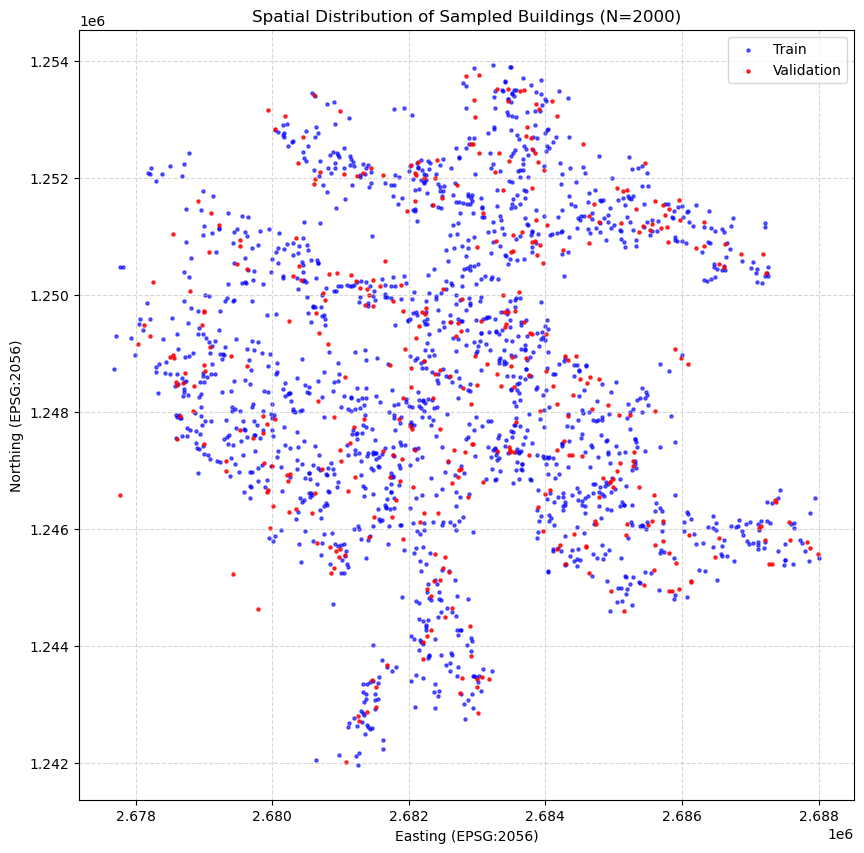

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Train samples
train_pts = gdf_sample[gdf_sample['split'] == 'train']
ax.scatter(train_pts['x_2056'], train_pts['y_2056'], 
           c='blue', s=5, alpha=0.6, label='Train')

# Plot Val samples
val_pts = gdf_sample[gdf_sample['split'] == 'val']
ax.scatter(val_pts['x_2056'], val_pts['y_2056'], 
           c='red', s=5, alpha=0.8, label='Validation')

ax.set_title(f"Spatial Distribution of Sampled Buildings (N={SAMPLE_SIZE})")
ax.set_xlabel("Easting (EPSG:2056)")
ax.set_ylabel("Northing (EPSG:2056)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 4. Save Spatial Anchors Metadata
We save this annotated GeoDataFrame as a `.gpkg`. In future notebooks, we will load this exact file to apply the same bounding boxes to the Biotope maps or Vegetation Height models, ensuring perfect spatial alignment.

In [30]:
metadata_path = f"{META_DIR}/building_anchors_{SAMPLE_SIZE}.gpkg"

# Save the GeoDataFrame
gdf_sample.to_file(metadata_path, driver="GPKG")
print(f"✅ Metadata saved to: {metadata_path}")

✅ Metadata saved to: ../data/processed_modular/metadata/building_anchors_2000.gpkg


## 5. Download Centered Image Crops from Swisstopo WMS
Instead of downloading massive gigabyte-sized TIFFs and cutting them locally, we leverage the Swisstopo WMS API. By requesting a specific bounding box (100x100 meters) and setting the image size to 1000x1000 pixels, the API dynamically returns perfectly formatted 10cm-resolution GeoTIFFs centered directly over our buildings.

In [31]:
CROP_RADIUS_M = 50      # Keep the 100x100m real-world bounding box
IMG_SIZE = 512          # Force the API to return a 512x512 tensor-friendly image
# PIXEL_RESOLUTION is effectively ~19.5cm now, handled automatically by WMS
# Base URL for Swisstopo Web Map Service
WMS_BASE_URL = "https://wms.geo.admin.ch/"

print(f"Downloading {len(gdf_sample)} images ({IMG_SIZE}x{IMG_SIZE}px) from Swisstopo API...")

successful = 0
failed = 0

# Loop through the sampled buildings
for idx, row in tqdm(gdf_sample.iterrows(), total=len(gdf_sample)):
    uid = row['unique_id']
    split = row['split']
    cx = row['x_2056']
    cy = row['y_2056']
    
    # Define the bounding box
    minx, maxx = cx - CROP_RADIUS_M, cx + CROP_RADIUS_M
    miny, maxy = cy - CROP_RADIUS_M, cy + CROP_RADIUS_M
    bbox_str = f"{minx},{miny},{maxx},{maxy}"
    
    # Destination path
    out_path = f"{BASE_OUT}/{split}/{IMG_DIR}/{uid}_swissimage.tif"
    
    # Skip if already downloaded
    if os.path.exists(out_path):
        successful += 1
        continue
        
    # Build the WMS request parameters
    params = {
        'SERVICE': 'WMS',
        'VERSION': '1.3.0',
        'REQUEST': 'GetMap',
        'LAYERS': 'ch.swisstopo.swissimage',
        'STYLES': 'default',
        'CRS': 'EPSG:2056',
        'BBOX': bbox_str,
        'WIDTH': IMG_SIZE,
        'HEIGHT': IMG_SIZE,
        'FORMAT': 'image/tiff'
    }
    
    try:
        # Request the image directly as a GeoTIFF
        response = requests.get(WMS_BASE_URL, params=params, timeout=10)
        
        if response.status_code == 200:
            with open(out_path, 'wb') as f:
                f.write(response.content)
            successful += 1
        else:
            print(f"Failed to download {uid}: HTTP {response.status_code}")
            failed += 1
            
    except Exception as e:
        print(f"Error downloading {uid}: {e}")
        failed += 1

print(f"\n✅ Download complete! Successfully retrieved {successful} images. Failed: {failed}")

  0%|          | 0/2000 [00:00<?, ?it/s]


✅ Download complete! Successfully retrieved 2000 images. Failed: 0
